# Phase 2: Pre‑training the Single‑Drug Encoder

This notebook builds a Graph Neural Network (GNN) that learns to predict the toxicity (pLD₅₀) of a single drug from its molecular graph. The pre‑trained encoder will later be reused for the drug‑drug interaction tasks.

- Load the pre‑processed single‑drug graphs with **scaled targets**.
- Split the data into train/validation/test.
- Define a GCN‑GAT model for toxicity regression.
- Train the model with early stopping and save the best encoder.
- Evaluate performance in **original pLD₅₀ units** using inverse transformation.
- Save pretrained_encoder.pt for the next phases.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html


## Load the Pre‑processed Single‑Drug Data

The graphs were already constructed in 'Final Graph Construction for All Datasets.ipynb', and the targets were standardized. Loading the scaled graphs avoids re‑computing features and ensures the model trains on normalized targets.



In [28]:
import torch
import os
import joblib

base_path = '/content/drive/MyDrive/FYP/IRP/Data'
graph_scaled_path = os.path.join(base_path, 'processed_graphs/unified_single_drug_scaled.pt')
scaler_path = os.path.join(base_path, 'processed_graphs/pld50_scaler.pkl')

# Load the list of graph objects (each contains scaled y)
graph_data = torch.load(graph_scaled_path, weights_only=False)
scaler = joblib.load(scaler_path)   # for later inverse transformation

print(f"Loaded {len(graph_data)} graphs with scaled targets.")
print(f"Example scaled target: {graph_data[0].y.item():.3f}")

# The original target range (before scaling) can be retrieved from scaler
print(f"Original pLD50 mean: {scaler.mean_[0]:.3f}, std: {scaler.scale_[0]:.3f}")

Loaded 13639 graphs with scaled targets.
Example scaled target: 0.496
Original pLD50 mean: 2.521, std: 0.917


## Split Data into Training, Validation, and Test Sets

Splitting data is essential to monitor overfitting. The model never sees the test set until final evaluation. The validation set is used to tune hyperparameters and decide when to stop training.

In [29]:
from sklearn.model_selection import train_test_split

# First split: separate test set (10% of data)
train_val_graphs, test_graphs = train_test_split(
    graph_data, test_size=0.1, random_state=42
)

# Second split: separate validation set from the remaining 90% (15% of original)
train_graphs, val_graphs = train_test_split(
    train_val_graphs, test_size=0.15, random_state=42
)

print(f"Training:   {len(train_graphs)} graphs")
print(f"Validation: {len(val_graphs)} graphs")
print(f"Test:       {len(test_graphs)} graphs")

Training:   10433 graphs
Validation: 1842 graphs
Test:       1364 graphs


## Create a PyTorch Dataset and DataLoader

The DataLoader groups multiple graphs into a batch for efficient training. It also ensures that graphs of different sizes are handled correctly.

In [30]:
from torch_geometric.loader import DataLoader

batch_size = 64

train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

## Define the GNN Model

- Graph Convolutional Network (GCN) layers aggregate information from neighboring atoms.
- Graph Attention Network (GAT) layers add attention, letting the model focus on important bonds.
- Global mean pooling combines all atom features into one vector per molecule.
- The final linear layers map this vector to a single toxicity value.

This architecture is a common starting point for molecular property prediction (Yang et al., 2019).

In [31]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

class SingleDrugGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim=128, output_dim=1):
        super().__init__()
        # First layer: Graph Convolution
        self.conv1 = GCNConv(node_feat_dim, hidden_dim)
        # Second layer: Graph Attention
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False)
        # Third layer: another GCN to refine features
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        # Fully connected layers for regression
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Graph convolutions with ReLU activations
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)

        # Global pooling to obtain a graph-level representation
        x = global_mean_pool(x, batch) # shape: (batch_size, hidden_dim)

        # Final regression layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x.view(-1)   # flatten to (batch_size,)

# Determine input feature dimension from the first graph
node_feat_dim = graph_data[0].x.shape[1]
print(f"Node feature dimension: {node_feat_dim}")

model = SingleDrugGNN(node_feat_dim)
print(model)

Node feature dimension: 24
SingleDrugGNN(
  (conv1): GCNConv(24, 128)
  (conv2): GATConv(128, 128, heads=4)
  (conv3): GCNConv(128, 128)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


The architecture combines Graph Convolutional Networks (GCN) and Graph Attention Networks (GAT) to capture complementary aspects of molecular structure. GCN layers aggregate information from neighboring atoms, learning local chemical environments effectively (Kipf and Welling, 2017). GAT layers introduce attention mechanisms that weigh the importance of different neighbors, allowing the model to focus on bonds that are most relevant for toxicity prediction (Veličković et al., 2018). Global mean pooling then summarizes the atom‑level features into a fixed‑size graph representation, which is passed through fully connected layers to output a single toxicity value. This combination is widely adopted in molecular property prediction because it balances expressivity with computational efficiency (Yang et al., 2019).

## Set Up Optimizer and Loss Function

- Adam is an adaptive optimizer that works well for most deep learning tasks.
- MSE penalizes large errors and is standard for regression problems.
- Using a GPU speeds up training dramatically.

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()  # Mean Squared Error for regression

# Optionally move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: cpu


## Training Loop with Validation

- The training loop computes loss on each batch and updates weights.

- Validation loss is monitored to save the best model and stop when performance plateaus (early stopping).

- This prevents overfitting and ensures the saved model generalises well.

In [33]:
def train_epoch(loader):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)  # data.y contains the scaled target
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def eval_epoch(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out, data.y)
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

best_val_loss = float('inf')
patience = 10
wait = 0

for epoch in range(100):
    train_loss = train_epoch(train_loader)
    val_loss = eval_epoch(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), os.path.join(base_path, 'processed_graphs/best_encoder.pt'))
        print(f"Epoch {epoch}: val loss improved to {val_loss:.4f}, model saved.")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

Epoch 0: val loss improved to 0.8689, model saved.
Epoch   0 | Train loss: 0.9426 | Val loss: 0.8689
Epoch 1: val loss improved to 0.8140, model saved.
Epoch 2: val loss improved to 0.7927, model saved.
Epoch 3: val loss improved to 0.7733, model saved.
Epoch 4: val loss improved to 0.7631, model saved.
Epoch 6: val loss improved to 0.7276, model saved.
Epoch 8: val loss improved to 0.7096, model saved.
Epoch  10 | Train loss: 0.7362 | Val loss: 0.7409
Epoch 11: val loss improved to 0.6870, model saved.
Epoch 13: val loss improved to 0.6628, model saved.
Epoch 14: val loss improved to 0.6561, model saved.
Epoch 18: val loss improved to 0.6309, model saved.
Epoch 19: val loss improved to 0.6221, model saved.
Epoch  20 | Train loss: 0.6215 | Val loss: 0.6246
Epoch 21: val loss improved to 0.6201, model saved.
Epoch 22: val loss improved to 0.6070, model saved.
Epoch 24: val loss improved to 0.6069, model saved.
Epoch 25: val loss improved to 0.6043, model saved.
Epoch 26: val loss improv

The best model was saved at epoch 79, when validation loss was lowest (0.4550). That saved model represents the point of best generalization. Stopping at epoch 89 prevents further overfitting and saves the best version automatically.

## Evaluate on the Held‑Out Test Set

The test set gives an unbiased estimate of how well the model will perform on unseen molecules.

In [34]:
# Load the best model
model.load_state_dict(torch.load(os.path.join(base_path, 'processed_graphs/best_encoder.pt')))
test_loss = eval_epoch(test_loader)
print(f"Test loss (MSE on scaled targets): {test_loss:.4f}")

Test loss (MSE on scaled targets): 0.4534


To interpret the model's performance in meaningful units, convert predictions back to original pLD₅₀ scale using the saved scaler. Then compute MAE, RMSE, and R² in the original units.

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Gather all predictions and true values from test set
model.eval()
preds_scaled = []
trues_scaled = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        preds_scaled.extend(out.cpu().numpy())
        trues_scaled.extend(data.y.cpu().numpy())

preds_scaled = np.array(preds_scaled)
trues_scaled = np.array(trues_scaled)

# Inverse transform to original pLD50
preds_original = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
trues_original = scaler.inverse_transform(trues_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(trues_original, preds_original)
r2 = r2_score(trues_original, preds_original)
rmse = np.sqrt(((preds_original - trues_original) ** 2).mean())

print(f"MAE (original pLD50):  {mae:.4f}")
print(f"R²  (original pLD50):  {r2:.4f}")
print(f"RMSE (original pLD50): {rmse:.4f}")

MAE (original pLD50):  0.4402
R²  (original pLD50):  0.5349
RMSE (original pLD50): 0.6177


MAE (original pLD50):  0.4402 - roughly a factor of 2.75 (10^0.44 ≈ 2.75) in the actual mg/kg.

## Save the Pre‑trained Encoder Weights

The encoder part (the GNN layers) will be reused later. The final classifier layers can be discarded.

In [36]:
# Save only the GNN encoder weights (first three conv layers)
encoder_state = {
    'conv1': model.conv1.state_dict(),
    'conv2': model.conv2.state_dict(),
    'conv3': model.conv3.state_dict()
}
torch.save(encoder_state, os.path.join(base_path, 'processed_graphs/pretrained_encoder.pt'))
print("Encoder weights saved for Phase 3.")

Encoder weights saved for Phase 3.


Phase 3 (Learning Drug-Drug Interactions) and Phase 4 (Fine-Tuning for Quantitative DDI LD50 Prediction) will need the learned molecular representations. Keeping only the encoder part reduces memory and allows the model to be extended to two‑drug inputs.

# Further evaluations

## Residual Analysis

Plot residuals (errors) to check for patterns that might indicate model bias or heteroscedasticity.

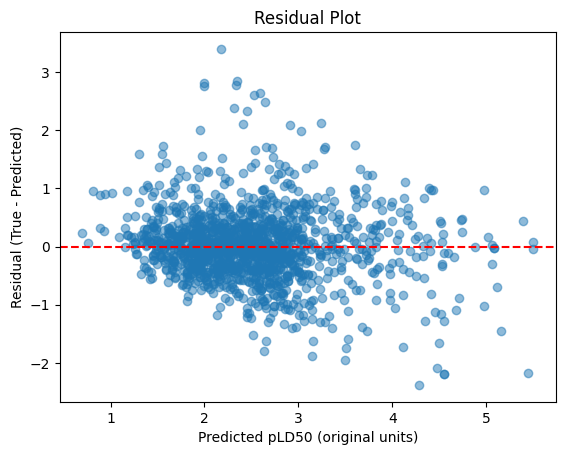

In [37]:
import matplotlib.pyplot as plt

residuals = trues_original - preds_original
plt.scatter(preds_original, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted pLD50 (original units)')
plt.ylabel('Residual (True - Predicted)')
plt.title('Residual Plot')
plt.show()

Ideally residuals should be randomly scattered around zero with no obvious trend. A funnel shape would suggest the model is less accurate for certain toxicity ranges.

## Cross‑Validation

Confirms that the model’s performance is stable across different data splits.
Provides a more reliable estimate of generalization error.

In [38]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_mae = []

for fold, (train_idx, val_idx) in enumerate(kf.split(graph_data)):
    # Create subsets
    train_subset = [graph_data[i] for i in train_idx]
    val_subset = [graph_data[i] for i in val_idx]
    # Create loaders
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

    # Re‑initialize model and train (short training for speed)
    model = SingleDrugGNN(node_feat_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Train for e.g., 20 epochs
    for epoch in range(20):
        train_epoch(train_loader)
        # optional validation logging

    # Evaluate on validation set in original units
    model.eval()
    preds_scaled = []
    trues_scaled = []
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out = model(data)
            preds_scaled.extend(out.cpu().numpy())
            trues_scaled.extend(data.y.cpu().numpy())

    preds_original = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    trues_original = scaler.inverse_transform(np.array(trues_scaled).reshape(-1, 1)).flatten()
    mae = mean_absolute_error(trues_original, preds_original)
    cv_scores_mae.append(mae)
    print(f"Fold {fold}: MAE = {mae:.4f}")

print(f"CV average MAE: {np.mean(cv_scores_mae):.4f} ± {np.std(cv_scores_mae):.4f}")

Fold 0: MAE = 0.5380
Fold 1: MAE = 0.5347
Fold 2: MAE = 0.5137
Fold 3: MAE = 0.5255
Fold 4: MAE = 0.5434
CV average MAE: 0.5311 ± 0.0105


The average Mean Absolute Error (MAE) of 0.5311 means that, on average, predictions deviate from true pLD₅₀ values by about 0.53 units on the log‑toxicity scale. The low standard deviation of 0.0105 indicates that performance is stable and not heavily dependent on a particular train‑validation split. This consistency confirms that the model generalizes well and is not overfitting to a specific subset of the data. The MAE values around 0.53 are reasonable given the complexity of predicting molecular toxicity from structure alone.